<a href="https://colab.research.google.com/github/TahirMaharaj/sc-interpretable-ml/blob/main/pbmc_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
   !pip install scanpy scikit-learn matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 976.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3
ERROR: pip's dependency resolver does not currently take 

  0%|          | 0.00/23.5M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: None (.X)


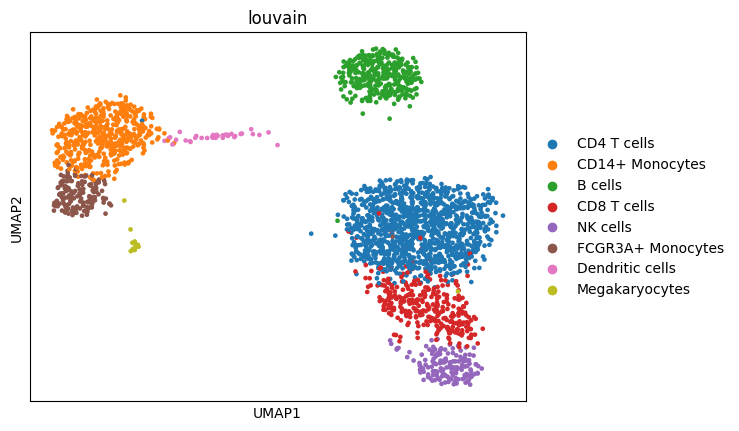

                   precision    recall  f1-score   support

          B cells       0.99      1.00      0.99        69
  CD14+ Monocytes       0.93      0.98      0.95        96
      CD4 T cells       0.94      0.97      0.95       229
      CD8 T cells       0.84      0.75      0.79        63
  Dendritic cells       1.00      0.71      0.83         7
FCGR3A+ Monocytes       0.93      0.87      0.90        30
   Megakaryocytes       1.00      0.67      0.80         3
         NK cells       0.93      0.87      0.90        31

         accuracy                           0.93       528
        macro avg       0.94      0.85      0.89       528
     weighted avg       0.93      0.93      0.93       528


B cells: CD79A, MS4A1, CD79B, HLA-DQB1, HLA-DQA1

CD14+ Monocytes: S100A8, LGALS2, MS4A6A, GPX1, FCN1

CD4 T cells: LTB, TNFRSF4, IL32, AQP3, MAL

CD8 T cells: CCL5, GZMK, NKG7, CST7, LYAR

Dendritic cells: FCER1A, CLEC10A, SERPINF1, ENHO, CD1C

FCGR3A+ Monocytes: FCGR3A, IFITM3, IFI30, 

In [2]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Load PBMC 3k dataset (public, with cell-type labels)
adata = sc.datasets.pbmc3k_processed()
print(adata)

# Visualise labelled cell types
sc.pl.umap(adata, color="louvain", show=True)


# Train/test split
X, y = adata.X, adata.obs["louvain"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Interpretable baseline: logistic regression
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)
print(classification_report(y_test, clf.predict(X_test)))

# Which genes drive each cell type? (interpretability)
genes = adata.var_names
for i, cell_type in enumerate(clf.classes_):
    top = pd.Series(clf.coef_[i], index=genes).nlargest(5)
    print(f"\n{cell_type}: {', '.join(top.index)}")